# SNAKE Experiments

Miguel Ángel Carrillo Cobián

COMP-579: Reinforcement Learning - Winter 2026

## Exploration

In [46]:
import numpy as np
np.bool8 = bool  # compatibility fix for some Gym/Numpy versions

import gym
import gym_snake_game
import time


ENV_ID = "Snake-v0"
NUM_EPISODES = 5
MAX_STEPS_PER_EPISODE = 200
RENDER = True


def explore_env():
    # Create environment
    env = gym.make(ENV_ID, render_mode="human" if RENDER else None, width=15, height=15)

    print("=" * 60)
    print("ENVIRONMENT INFORMATION")
    print("=" * 60)
    print(f"Environment ID: {ENV_ID}")
    print(f"Observation space: {env.observation_space}")
    print(f"Action space: {env.action_space}")

    # Reset once to inspect initial observation
    state, info = env.reset()

    print("\nINITIAL OBSERVATION INFORMATION")
    print("=" * 60)
    print(f"Type of state: {type(state)}")
    if isinstance(state, np.ndarray):
        print(f"State shape: {state.shape}")
        print(f"State dtype: {state.dtype}")
        print(f"State min: {state.min()}")
        print(f"State max: {state.max()}")
        print("Sample state:")
        print(state)
    else:
        print("State:", state)

    print("\nACTION MEANING ASSUMPTION")
    print("=" * 60)
    print("Based on your human-control code:")
    print("0 = UP")
    print("1 = DOWN")
    print("2 = LEFT")
    print("3 = RIGHT")

    all_episode_rewards = []
    all_episode_lengths = []

    print("\nSTARTING RANDOM EXPLORATION")
    print("=" * 60)

    for ep in range(NUM_EPISODES):
        state, info = env.reset()
        done = False
        total_reward = 0
        step_count = 0

        print(f"\nEpisode {ep + 1}")

        while not done and step_count < MAX_STEPS_PER_EPISODE:
            # Sample random action from action space
            action = env.action_space.sample()

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            print(
                f"Step {step_count:03d} | "
                f"Action: {action} | "
                f"Reward: {reward:.3f} | "
                f"Done: {done}"
            )

            total_reward += reward
            step_count += 1
            state = next_state

            if RENDER:
                time.sleep(0.1)

        all_episode_rewards.append(total_reward)
        all_episode_lengths.append(step_count)

        print(f"Episode {ep + 1} finished")
        print(f"  Total reward: {total_reward}")
        print(f"  Episode length: {step_count}")

    env.close()

    print("\nSUMMARY")
    print("=" * 60)
    print(f"Number of episodes: {NUM_EPISODES}")
    print(f"Average reward: {np.mean(all_episode_rewards):.3f}")
    print(f"Std reward: {np.std(all_episode_rewards):.3f}")
    print(f"Average episode length: {np.mean(all_episode_lengths):.3f}")
    print(f"Std episode length: {np.std(all_episode_lengths):.3f}")


if __name__ == "__main__":
    explore_env()

ENVIRONMENT INFORMATION
Environment ID: Snake-v0
Observation space: Box(-inf, inf, (6,), float32)
Action space: Discrete(4)

INITIAL OBSERVATION INFORMATION
Type of state: <class 'numpy.ndarray'>
State shape: (6,)
State dtype: float32
State min: -0.8137334585189819
State max: 0.5812382102012634
Sample state:
[ 0.5812382  -0.81373346  0.46666667  0.46666667  0.          0.46666667]

ACTION MEANING ASSUMPTION
Based on your human-control code:
0 = UP
1 = DOWN
2 = LEFT
3 = RIGHT

STARTING RANDOM EXPLORATION

Episode 1
Step 000 | Action: 1 | Reward: 0.231 | Done: False
Step 001 | Action: 0 | Reward: 0.096 | Done: False
Step 002 | Action: 2 | Reward: 0.042 | Done: False
Step 003 | Action: 3 | Reward: -0.030 | Done: False
Step 004 | Action: 0 | Reward: 0.085 | Done: False
Step 005 | Action: 2 | Reward: -0.010 | Done: False
Step 006 | Action: 1 | Reward: -0.116 | Done: False
Step 007 | Action: 2 | Reward: -0.212 | Done: False
Step 008 | Action: 0 | Reward: -0.116 | Done: False
Step 009 | Actio

### Environment Observation and Action Space

The Snake environment provides observations as a NumPy array:

* **Type:** `numpy.ndarray`
* **Shape:** `(6,)`
* **Data type:** `float32`
* **Range:** approximately `[-1, 1]`
* **Observation space:** `Box(-1.0, 1.0, (6,), float32)`

This means that each state is represented as a **6-dimensional continuous feature vector** describing the local configuration of the game.

The features encode **relative information about the environment**, including:

* **Direction to the food** (horizontal and vertical components)
* **Potential danger around the snake** (e.g., proximity to walls or its own body)

This compact representation allows the agent to understand **where the food is located and which directions may lead to collisions**, without using the full grid of the game.

The **action space** is:

* **Type:** `Discrete(4)`
* `0` → move **up**
* `1` → move **down**
* `2` → move **left**
* `3` → move **right**

Because the observation is a **small feature vector rather than a grid or image**, the agent can be trained using a **multilayer perceptron (MLP)** instead of a convolutional neural network.

This compact state representation enables efficient reinforcement learning and allows us to compare the performance of **standard DQN** and **Deep Q-learning from Demonstrations (DQfD)** under the same environment conditions.


## DQN Calibration

In [47]:
import random
from collections import deque, namedtuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def preprocess_obs(obs):
    """
    Snake observations are already a compact 6-dimensional feature vector.
    Convert to float32 for PyTorch.
    """
    obs = np.asarray(obs, dtype=np.float32)
    return obs


class DQN(nn.Module):
    def __init__(self, state_dim=6, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)


Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


def select_action(state, q_network, epsilon, n_actions=4):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


def train_step(q_network, target_network, replay_buffer, optimizer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    current_q = q_network(states).gather(1, actions)

    with torch.no_grad():
        max_next_q = target_network(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + gamma * max_next_q * (1.0 - dones)

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


def train_dqn(
    num_episodes=500,
    max_steps_per_episode=500,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=50000,
    min_buffer_size=1000,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
):
    env = gym.make("Snake-v0", render_mode=None, width=15, height=15)

    state_dim = 6
    n_actions = env.action_space.n

    q_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(buffer_capacity)

    epsilon = epsilon_start

    episode_rewards = []
    losses = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        state = preprocess_obs(obs)

        done = False
        total_reward = 0.0
        episode_loss_values = []

        for step in range(max_steps_per_episode):
            action = select_action(state, q_network, epsilon, n_actions)

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            next_state = preprocess_obs(next_obs)

            replay_buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(replay_buffer) >= min_buffer_size:
                loss = train_step(
                    q_network=q_network,
                    target_network=target_network,
                    replay_buffer=replay_buffer,
                    optimizer=optimizer,
                    batch_size=batch_size,
                    gamma=gamma,
                )
                if loss is not None:
                    episode_loss_values.append(loss)

            if done:
                break

        episode_rewards.append(total_reward)

        if episode_loss_values:
            losses.append(np.mean(episode_loss_values))
        else:
            losses.append(np.nan)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % target_update_freq == 0:
            target_network.load_state_dict(q_network.state_dict())

        if (episode + 1) % 10 == 0:
            recent_rewards = episode_rewards[-10:]
            print(
                f"Episode {episode + 1:4d} | "
                f"Avg Reward (last 10): {np.mean(recent_rewards):7.3f} | "
                f"Epsilon: {epsilon:6.3f}"
            )

    env.close()
    return q_network, target_network, episode_rewards, losses


q_network, target_network, episode_rewards, losses = train_dqn(
    num_episodes=100,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
)

Using device: cpu
Episode   10 | Avg Reward (last 10):  -4.306 | Epsilon:  0.951
Episode   20 | Avg Reward (last 10):   1.690 | Epsilon:  0.905
Episode   30 | Avg Reward (last 10):  -0.210 | Epsilon:  0.860
Episode   40 | Avg Reward (last 10):   1.673 | Epsilon:  0.818
Episode   50 | Avg Reward (last 10):   3.102 | Epsilon:  0.778
Episode   60 | Avg Reward (last 10):  -1.752 | Epsilon:  0.740
Episode   70 | Avg Reward (last 10):   6.621 | Epsilon:  0.704
Episode   80 | Avg Reward (last 10):   2.556 | Epsilon:  0.670
Episode   90 | Avg Reward (last 10):   4.086 | Epsilon:  0.637
Episode  100 | Avg Reward (last 10):  11.611 | Epsilon:  0.606


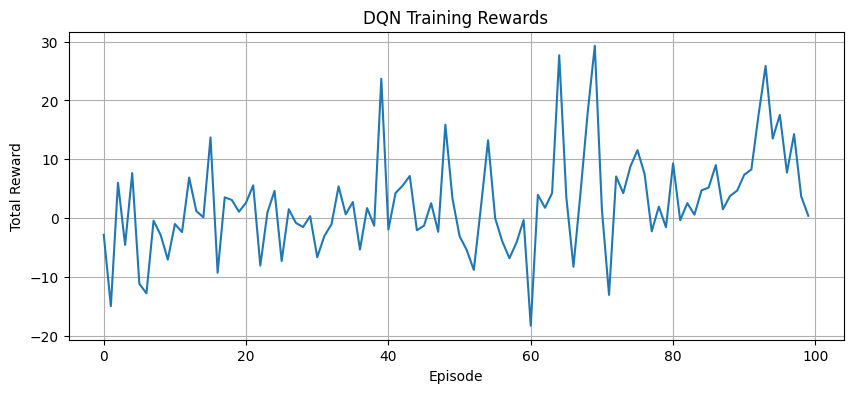

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training Rewards")
plt.grid(True)
plt.show()

In [49]:
def evaluate_policy(q_network, num_episodes=5, max_steps_per_episode=1000, render_mode="human"):
    env = gym.make("Snake-v0", render_mode='human', width=15, height=15)

    rewards = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        state = preprocess_obs(obs)
        done = False
        total_reward = 0.0

        for step in range(max_steps_per_episode):
            state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                action = int(torch.argmax(q_network(state_tensor), dim=1).item())

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            state = preprocess_obs(next_obs)
            total_reward += reward

            if done:
                break

        rewards.append(total_reward)
        print(f"Evaluation episode {episode + 1}: reward = {total_reward:.2f}")

    env.close()
    print("Average evaluation reward:", np.mean(rewards))
    return rewards

In [50]:
eval_rewards = evaluate_policy(q_network, num_episodes=3, render_mode="human")

Evaluation episode 1: reward = 324.57
Evaluation episode 2: reward = 136.49
Evaluation episode 3: reward = 34.66
Average evaluation reward: 165.23735978925995


## Experimentation

### BASELINE DQN

In [51]:
import os
import pickle
import random
from collections import deque, namedtuple

import gym
import gym_snake_game
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

np.bool8 = bool  # compatibility fix if needed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def preprocess_obs(obs):
    """
    Snake observation is already a compact 6-dimensional feature vector.
    Convert to float32 for PyTorch.
    """
    obs = np.asarray(obs, dtype=np.float32)
    return obs


class DQN(nn.Module):
    def __init__(self, state_dim=6, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)


Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


def select_action(state, q_network, epsilon, n_actions=4):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


def train_step(q_network, target_network, replay_buffer, optimizer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    current_q = q_network(states).gather(1, actions)

    with torch.no_grad():
        max_next_q = target_network(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + gamma * max_next_q * (1.0 - dones)

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


def train_dqn(
    seed,
    num_episodes=500,
    max_steps_per_episode=500,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=50000,
    min_buffer_size=1000,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    width=15,
    height=15,
    step_penalty=0,
):
    set_seed(seed)

    env = gym.make("Snake-v0", render_mode=None, width=width, height=height)

    state_dim = 6
    n_actions = env.action_space.n

    q_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(buffer_capacity)

    epsilon = epsilon_start

    episode_rewards = []
    losses = []
    epsilons = []

    for episode in range(num_episodes):
        reset_out = env.reset()

        # compatible with either gym or gymnasium-style reset
        if isinstance(reset_out, tuple) and len(reset_out) == 2:
            obs, info = reset_out
        else:
            obs = reset_out
            info = {}

        state = preprocess_obs(obs)

        done = False
        total_reward = 0.0
        episode_loss_values = []

        for step in range(max_steps_per_episode):
            action = select_action(state, q_network, epsilon, n_actions)

            step_out = env.step(action)

            # compatible with both APIs
            if len(step_out) == 5:
                next_obs, reward, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                next_obs, reward, done, info = step_out

            # small negative reward per step to discourage loops
            reward -= step_penalty

            next_state = preprocess_obs(next_obs)

            replay_buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(replay_buffer) >= min_buffer_size:
                loss = train_step(
                    q_network=q_network,
                    target_network=target_network,
                    replay_buffer=replay_buffer,
                    optimizer=optimizer,
                    batch_size=batch_size,
                    gamma=gamma,
                )
                if loss is not None:
                    episode_loss_values.append(loss)

            if done:
                break

        episode_rewards.append(total_reward)
        epsilons.append(epsilon)

        if episode_loss_values:
            losses.append(float(np.mean(episode_loss_values)))
        else:
            losses.append(np.nan)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % target_update_freq == 0:
            target_network.load_state_dict(q_network.state_dict())

        if (episode + 1) % 10 == 0:
            recent_rewards = episode_rewards[-10:]
            print(
                f"[Seed {seed}] Episode {episode + 1:4d} | "
                f"Avg Reward (last 10): {np.mean(recent_rewards):7.3f} | "
                f"Epsilon: {epsilon:6.3f}"
            )

    env.close()

    return {
        "seed": seed,
        "episode_rewards": episode_rewards,
        "losses": losses,
        "epsilons": epsilons,
        "final_epsilon": epsilon,
        "q_network_state_dict": q_network.state_dict(),
        "target_network_state_dict": target_network.state_dict(),
    }


def run_experiment(seeds, save_dir="dqn_results", save_models=True, **train_kwargs):
    os.makedirs(save_dir, exist_ok=True)

    all_results = {
        "seeds": list(seeds),
        "config": train_kwargs,
        "runs": []
    }

    for seed in seeds:
        print(f"\n{'='*70}")
        print(f"Starting training for seed {seed}")
        print(f"{'='*70}")

        run_result = train_dqn(seed=seed, **train_kwargs)
        all_results["runs"].append(
            {
                "seed": run_result["seed"],
                "episode_rewards": run_result["episode_rewards"],
                "losses": run_result["losses"],
                "epsilons": run_result["epsilons"],
                "final_epsilon": run_result["final_epsilon"],
            }
        )

        if save_models:
            torch.save(
                run_result["q_network_state_dict"],
                os.path.join(save_dir, f"q_network_seed_{seed}.pt")
            )
            torch.save(
                run_result["target_network_state_dict"],
                os.path.join(save_dir, f"target_network_seed_{seed}.pt")
            )

    rewards_array = np.array([run["episode_rewards"] for run in all_results["runs"]], dtype=np.float32)
    losses_array = np.array([run["losses"] for run in all_results["runs"]], dtype=np.float32)

    all_results["summary"] = {
        "mean_episode_rewards": np.mean(rewards_array, axis=0),
        "std_episode_rewards": np.std(rewards_array, axis=0),
        "mean_losses": np.nanmean(losses_array, axis=0),
        "std_losses": np.nanstd(losses_array, axis=0),
    }

    with open(os.path.join(save_dir, "training_results.pkl"), "wb") as f:
        pickle.dump(all_results, f)

    np.save(os.path.join(save_dir, "mean_episode_rewards.npy"), all_results["summary"]["mean_episode_rewards"])
    np.save(os.path.join(save_dir, "std_episode_rewards.npy"), all_results["summary"]["std_episode_rewards"])
    np.save(os.path.join(save_dir, "mean_losses.npy"), all_results["summary"]["mean_losses"])
    np.save(os.path.join(save_dir, "std_losses.npy"), all_results["summary"]["std_losses"])

    return all_results


# Run across 3 seeds
seeds = [42, 123, 999]

results = run_experiment(
    seeds=seeds,
    save_dir="dqn_snake_3seeds",
    save_models=True,
    num_episodes=1000,
    max_steps_per_episode=500,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    width=15,
    height=15,
    step_penalty=0,
)

print("\nFinished training across all seeds.")
print("Saved results to: dqn_snake_3seeds")

Using device: cpu

Starting training for seed 42
[Seed 42] Episode   10 | Avg Reward (last 10):  -4.306 | Epsilon:  0.951
[Seed 42] Episode   20 | Avg Reward (last 10):   1.690 | Epsilon:  0.905
[Seed 42] Episode   30 | Avg Reward (last 10):  -0.210 | Epsilon:  0.860
[Seed 42] Episode   40 | Avg Reward (last 10):   1.673 | Epsilon:  0.818
[Seed 42] Episode   50 | Avg Reward (last 10):   3.102 | Epsilon:  0.778
[Seed 42] Episode   60 | Avg Reward (last 10):  -1.752 | Epsilon:  0.740
[Seed 42] Episode   70 | Avg Reward (last 10):   6.621 | Epsilon:  0.704
[Seed 42] Episode   80 | Avg Reward (last 10):   2.556 | Epsilon:  0.670
[Seed 42] Episode   90 | Avg Reward (last 10):   4.086 | Epsilon:  0.637
[Seed 42] Episode  100 | Avg Reward (last 10):  11.611 | Epsilon:  0.606
[Seed 42] Episode  110 | Avg Reward (last 10):  10.254 | Epsilon:  0.576
[Seed 42] Episode  120 | Avg Reward (last 10):  10.557 | Epsilon:  0.548
[Seed 42] Episode  130 | Avg Reward (last 10):   9.884 | Epsilon:  0.521
[S

C:\Users\mikel\AppData\Local\Temp\ipykernel_1312\3844525946.py:279: RuntimeWarning: Mean of empty slice
  "mean_losses": np.nanmean(losses_array, axis=0),
d:\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### DGFD: 10 EPISODES

In [52]:
import os
import pickle
import random
from collections import namedtuple

import gym
import gym_snake_game
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

np.bool8 = bool  # compatibility fix if needed


# ============================================================
# Device / reproducibility
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# Observation preprocessing: Snake already uses 6 features
# ============================================================

def preprocess_obs(obs):
    obs = np.asarray(obs, dtype=np.float32)
    return obs


# ============================================================
# Q-network
# ============================================================

class DQN(nn.Module):
    def __init__(self, state_dim=6, n_actions=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Prioritized Replay Buffer with demo retention
# ============================================================

Transition = namedtuple(
    "Transition",
    [
        "state",
        "action",
        "reward",
        "next_state",
        "done",
        "n_step_reward",
        "n_step_next_state",
        "n_step_done",
        "is_demo",
    ],
)


class PrioritizedReplayBuffer:
    """
    Simple proportional prioritized replay buffer.

    Key DQfD behaviors:
    - demo data can be marked permanent so it is never overwritten
    - each sample has a priority
    - importance sampling weights are returned
    """

    def __init__(self, capacity, alpha=0.6, demo_epsilon=1.0):
        self.capacity = capacity
        self.alpha = alpha
        self.demo_epsilon = demo_epsilon

        self.storage = []
        self.priorities = []

        self.demo_size = 0
        self.next_idx = 0

    def __len__(self):
        return len(self.storage)

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done,
        n_step_reward,
        n_step_next_state,
        n_step_done,
        is_demo=False,
        priority=None,
    ):
        transition = Transition(
            state=np.asarray(state, dtype=np.float32),
            action=int(action),
            reward=float(reward),
            next_state=np.asarray(next_state, dtype=np.float32),
            done=bool(done),
            n_step_reward=float(n_step_reward),
            n_step_next_state=np.asarray(n_step_next_state, dtype=np.float32),
            n_step_done=bool(n_step_done),
            is_demo=bool(is_demo),
        )

        if priority is None:
            max_prio = max(self.priorities) if self.priorities else 1.0
            priority = max_prio

        if is_demo:
            self.storage.append(transition)
            self.priorities.append(float(priority) + self.demo_epsilon)
            self.demo_size += 1
            self.next_idx = self.demo_size
            return

        if len(self.storage) < self.capacity:
            self.storage.append(transition)
            self.priorities.append(float(priority))
        else:
            if self.demo_size >= self.capacity:
                raise ValueError("Replay buffer capacity is too small to hold permanent demos.")

            idx = self.next_idx
            if idx < self.demo_size:
                idx = self.demo_size

            self.storage[idx] = transition
            self.priorities[idx] = float(priority)

            self.next_idx += 1
            if self.next_idx >= self.capacity:
                self.next_idx = self.demo_size

    def sample(self, batch_size, beta=0.4):
        if len(self.storage) < batch_size:
            return None

        priorities = np.asarray(self.priorities, dtype=np.float64)
        scaled = priorities ** self.alpha
        probs = scaled / scaled.sum()

        indices = np.random.choice(len(self.storage), size=batch_size, replace=False, p=probs)
        samples = [self.storage[i] for i in indices]

        N = len(self.storage)
        weights = (N * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = {
            "indices": indices,
            "weights": np.asarray(weights, dtype=np.float32),
            "states": np.asarray([t.state for t in samples], dtype=np.float32),
            "actions": np.asarray([t.action for t in samples], dtype=np.int64),
            "rewards": np.asarray([t.reward for t in samples], dtype=np.float32),
            "next_states": np.asarray([t.next_state for t in samples], dtype=np.float32),
            "dones": np.asarray([t.done for t in samples], dtype=np.float32),
            "n_step_rewards": np.asarray([t.n_step_reward for t in samples], dtype=np.float32),
            "n_step_next_states": np.asarray([t.n_step_next_state for t in samples], dtype=np.float32),
            "n_step_dones": np.asarray([t.n_step_done for t in samples], dtype=np.float32),
            "is_demo": np.asarray([t.is_demo for t in samples], dtype=np.float32),
        }
        return batch

    def update_priorities(self, indices, priorities):
        for idx, prio in zip(indices, priorities):
            bonus = self.demo_epsilon if self.storage[idx].is_demo else 0.0
            self.priorities[idx] = float(max(prio, 1e-6) + bonus)


# ============================================================
# Action selection
# ============================================================

def select_action(state, q_network, epsilon, n_actions=4):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


# ============================================================
# N-step utilities
# ============================================================

def build_n_step_episode(episode, n_step=10, gamma=0.99):
    processed = []
    T = len(episode)

    for i in range(T):
        cumulative_reward = 0.0
        final_next_state = episode[i]["next_state"]
        final_done = episode[i]["done"]

        for k in range(n_step):
            j = i + k
            if j >= T:
                break

            cumulative_reward += (gamma ** k) * float(episode[j]["reward"])
            final_next_state = episode[j]["next_state"]
            final_done = bool(episode[j]["done"])

            if final_done:
                break

        processed.append(
            {
                "state": episode[i]["state"],
                "action": int(episode[i]["action"]),
                "reward": float(episode[i]["reward"]),
                "next_state": episode[i]["next_state"],
                "done": bool(episode[i]["done"]),
                "n_step_reward": float(cumulative_reward),
                "n_step_next_state": final_next_state,
                "n_step_done": final_done,
            }
        )

    return processed


# ============================================================
# Demo loading
# ============================================================

def load_demo_episodes(
    demo_file,
    num_demo_episodes,
    n_step=10,
    gamma=0.99,
    random_selection=False,
):
    with open(demo_file, "rb") as f:
        all_episodes = pickle.load(f)

    if num_demo_episodes > len(all_episodes):
        raise ValueError(
            f"Requested {num_demo_episodes} demo episodes, but file contains {len(all_episodes)}."
        )

    if random_selection:
        selected_indices = random.sample(range(len(all_episodes)), num_demo_episodes)
        selected = [all_episodes[i] for i in selected_indices]
    else:
        selected_indices = list(range(num_demo_episodes))
        selected = all_episodes[:num_demo_episodes]

    processed_episodes = []

    for ep in selected:
        clean_ep = []
        for tr in ep:
            clean_ep.append(
                {
                    "state": preprocess_obs(tr["state"]),
                    "action": int(tr["action"]),
                    "reward": float(tr["reward"]),
                    "next_state": preprocess_obs(tr["next_state"]),
                    "done": bool(tr["done"]),
                }
            )
        processed_episodes.append(build_n_step_episode(clean_ep, n_step=n_step, gamma=gamma))

    return processed_episodes, selected_indices


def add_demo_data_to_buffer(replay_buffer, demo_episodes):
    num_transitions = 0
    episode_lengths = []

    for ep in demo_episodes:
        episode_lengths.append(len(ep))
        for tr in ep:
            replay_buffer.add(
                state=tr["state"],
                action=tr["action"],
                reward=tr["reward"],
                next_state=tr["next_state"],
                done=tr["done"],
                n_step_reward=tr["n_step_reward"],
                n_step_next_state=tr["n_step_next_state"],
                n_step_done=tr["n_step_done"],
                is_demo=True,
                priority=1.0,
            )
            num_transitions += 1

    return {
        "num_demo_episodes_used": len(demo_episodes),
        "num_demo_transitions": num_transitions,
        "episode_lengths": episode_lengths,
    }


# ============================================================
# DQfD loss
# ============================================================

def large_margin_supervised_loss(q_values, expert_actions, is_demo_mask, margin=0.8):
    if is_demo_mask.sum().item() == 0:
        return torch.tensor(0.0, device=q_values.device)

    actions = expert_actions.view(-1, 1)

    margins = torch.full_like(q_values, fill_value=margin)
    margins.scatter_(1, actions, 0.0)

    margin_q = q_values + margins
    max_margin_q, _ = margin_q.max(dim=1)

    expert_q = q_values.gather(1, actions).squeeze(1)
    per_sample = max_margin_q - expert_q

    demo_losses = per_sample * is_demo_mask
    return demo_losses.sum() / is_demo_mask.sum().clamp(min=1.0)


def dqfd_train_step(
    q_network,
    target_network,
    replay_buffer,
    optimizer,
    batch_size,
    gamma=0.99,
    n_step=10,
    beta=0.4,
    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
):
    batch = replay_buffer.sample(batch_size, beta=beta)
    if batch is None:
        return None

    states = torch.tensor(batch["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(batch["actions"], dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(batch["rewards"], dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(batch["next_states"], dtype=torch.float32, device=device)
    dones = torch.tensor(batch["dones"], dtype=torch.float32, device=device).unsqueeze(1)

    n_step_rewards = torch.tensor(batch["n_step_rewards"], dtype=torch.float32, device=device).unsqueeze(1)
    n_step_next_states = torch.tensor(batch["n_step_next_states"], dtype=torch.float32, device=device)
    n_step_dones = torch.tensor(batch["n_step_dones"], dtype=torch.float32, device=device).unsqueeze(1)

    is_demo = torch.tensor(batch["is_demo"], dtype=torch.float32, device=device)
    weights = torch.tensor(batch["weights"], dtype=torch.float32, device=device).unsqueeze(1)

    q_values = q_network(states)
    current_q = q_values.gather(1, actions)

    with torch.no_grad():
        if use_double_dqn:
            next_actions_1 = q_network(next_states).argmax(dim=1, keepdim=True)
            next_q_1 = target_network(next_states).gather(1, next_actions_1)

            next_actions_n = q_network(n_step_next_states).argmax(dim=1, keepdim=True)
            next_q_n = target_network(n_step_next_states).gather(1, next_actions_n)
        else:
            next_q_1 = target_network(next_states).max(dim=1, keepdim=True)[0]
            next_q_n = target_network(n_step_next_states).max(dim=1, keepdim=True)[0]

        target_1 = rewards + gamma * next_q_1 * (1.0 - dones)
        target_n = n_step_rewards + (gamma ** n_step) * next_q_n * (1.0 - n_step_dones)

    td_error_1 = current_q - target_1
    td_error_n = current_q - target_n

    loss_1 = (weights * td_error_1.pow(2)).mean()
    loss_n = (weights * td_error_n.pow(2)).mean()
    loss_je = large_margin_supervised_loss(
        q_values=q_values,
        expert_actions=actions.squeeze(1),
        is_demo_mask=is_demo,
        margin=margin,
    )

    l2_reg = torch.tensor(0.0, device=device)
    for p in q_network.parameters():
        l2_reg = l2_reg + p.pow(2).sum()

    total_loss = (
        lambda_dq * loss_1
        + lambda_n * loss_n
        + lambda_je * loss_je
        + lambda_l2 * l2_reg
    )

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    with torch.no_grad():
        priorities = (
            td_error_1.abs().squeeze(1).cpu().numpy()
            + td_error_n.abs().squeeze(1).cpu().numpy()
        )
        replay_buffer.update_priorities(batch["indices"], priorities)

    return {
        "total_loss": float(total_loss.item()),
        "loss_1step": float(loss_1.item()),
        "loss_nstep": float(loss_n.item()),
        "loss_margin": float(loss_je.item()),
        "mean_priority": float(np.mean(priorities)),
    }


# ============================================================
# Online episode collection with n-step bookkeeping
# ============================================================

def add_online_episode_to_buffer(replay_buffer, episode_transitions, n_step=10, gamma=0.99):
    processed = build_n_step_episode(episode_transitions, n_step=n_step, gamma=gamma)
    for tr in processed:
        replay_buffer.add(
            state=tr["state"],
            action=tr["action"],
            reward=tr["reward"],
            next_state=tr["next_state"],
            done=tr["done"],
            n_step_reward=tr["n_step_reward"],
            n_step_next_state=tr["n_step_next_state"],
            n_step_done=tr["n_step_done"],
            is_demo=False,
            priority=1.0,
        )


# ============================================================
# Full DQfD training
# ============================================================

def train_dqfd(
    seed,
    demo_file="snake_human_demos1.pkl",
    num_demo_episodes=10,
    num_episodes=500,
    max_steps_per_episode=500,
    pretrain_steps=1000,
    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=50000,
    min_buffer_size=500,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,
    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
    width=15,
    height=15,
    step_penalty=0,
):
    set_seed(seed)

    env = gym.make("Snake-v0", render_mode=None, width=width, height=height)

    q_network = DQN(state_dim=6, n_actions=env.action_space.n).to(device)
    target_network = DQN(state_dim=6, n_actions=env.action_space.n).to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=lr)

    replay_buffer = PrioritizedReplayBuffer(
        capacity=buffer_capacity,
        alpha=per_alpha,
        demo_epsilon=1.0,
    )

    demo_episodes, selected_demo_indices = load_demo_episodes(
        demo_file=demo_file,
        num_demo_episodes=num_demo_episodes,
        n_step=n_step,
        gamma=gamma,
        random_selection=True,
    )

    demo_stats = add_demo_data_to_buffer(replay_buffer, demo_episodes)
    demo_stats["selected_demo_indices"] = selected_demo_indices

    print(
        f"Loaded {demo_stats['num_demo_episodes_used']} demo episodes "
        f"({demo_stats['num_demo_transitions']} transitions)."
    )

    pretrain_logs = []
    gradient_updates = 0

    if pretrain_steps > 0:
        print(f"Starting DQfD pretraining for {pretrain_steps} steps...")
        for step in range(pretrain_steps):
            beta = per_beta_start + (per_beta_end - per_beta_start) * (step / max(pretrain_steps - 1, 1))

            log = dqfd_train_step(
                q_network=q_network,
                target_network=target_network,
                replay_buffer=replay_buffer,
                optimizer=optimizer,
                batch_size=batch_size,
                gamma=gamma,
                n_step=n_step,
                beta=beta,
                lambda_dq=lambda_dq,
                lambda_n=lambda_n,
                lambda_je=lambda_je,
                lambda_l2=lambda_l2,
                margin=margin,
                use_double_dqn=use_double_dqn,
            )

            if log is not None:
                pretrain_logs.append(log)
                gradient_updates += 1

            if gradient_updates % target_update_freq == 0:
                target_network.load_state_dict(q_network.state_dict())

            if (step + 1) % 100 == 0:
                print(
                    f"Pretrain {step + 1:4d}/{pretrain_steps} | "
                    f"total={log['total_loss']:.4f} | "
                    f"1step={log['loss_1step']:.4f} | "
                    f"nstep={log['loss_nstep']:.4f} | "
                    f"margin={log['loss_margin']:.4f}"
                )

        target_network.load_state_dict(q_network.state_dict())
        print("Finished pretraining.")

    epsilon = epsilon_start
    episode_rewards = []
    episode_loss = []
    episode_margin_loss = []
    epsilons = []

    for episode in range(num_episodes):
        reset_out = env.reset()

        if isinstance(reset_out, tuple) and len(reset_out) == 2:
            obs, info = reset_out
        else:
            obs = reset_out
            info = {}

        state = preprocess_obs(obs)

        done = False
        total_reward = 0.0
        online_episode = []
        logs_this_episode = []

        for step in range(max_steps_per_episode):
            action = select_action(state, q_network, epsilon, env.action_space.n)

            step_out = env.step(action)

            if len(step_out) == 5:
                next_obs, reward, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                next_obs, reward, done, info = step_out

            reward = float(reward) - step_penalty
            next_state = preprocess_obs(next_obs)

            online_episode.append(
                {
                    "state": state,
                    "action": action,
                    "reward": reward,
                    "next_state": next_state,
                    "done": done,
                }
            )

            state = next_state
            total_reward += reward

            if len(replay_buffer) >= min_buffer_size:
                progress = episode / max(num_episodes - 1, 1)
                beta = per_beta_start + (per_beta_end - per_beta_start) * progress

                log = dqfd_train_step(
                    q_network=q_network,
                    target_network=target_network,
                    replay_buffer=replay_buffer,
                    optimizer=optimizer,
                    batch_size=batch_size,
                    gamma=gamma,
                    n_step=n_step,
                    beta=beta,
                    lambda_dq=lambda_dq,
                    lambda_n=lambda_n,
                    lambda_je=lambda_je,
                    lambda_l2=lambda_l2,
                    margin=margin,
                    use_double_dqn=use_double_dqn,
                )
                if log is not None:
                    logs_this_episode.append(log)
                    gradient_updates += 1

                if gradient_updates % target_update_freq == 0:
                    target_network.load_state_dict(q_network.state_dict())

            if done:
                break

        add_online_episode_to_buffer(replay_buffer, online_episode, n_step=n_step, gamma=gamma)

        episode_rewards.append(float(total_reward))
        epsilons.append(float(epsilon))

        if logs_this_episode:
            episode_loss.append(float(np.mean([x["total_loss"] for x in logs_this_episode])))
            episode_margin_loss.append(float(np.mean([x["loss_margin"] for x in logs_this_episode])))
        else:
            episode_loss.append(np.nan)
            episode_margin_loss.append(np.nan)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % 10 == 0:
            print(
                f"[Seed {seed}] Episode {episode + 1:4d} | "
                f"AvgReward(10)={np.mean(episode_rewards[-10:]):7.3f} | "
                f"Eps={epsilon:6.3f} | "
                f"Replay={len(replay_buffer)}"
            )

    env.close()

    return {
        "seed": seed,
        "demo_stats": demo_stats,
        "episode_rewards": episode_rewards,
        "episode_loss": episode_loss,
        "episode_margin_loss": episode_margin_loss,
        "epsilons": epsilons,
        "pretrain_logs": pretrain_logs,
        "q_network_state_dict": q_network.state_dict(),
        "target_network_state_dict": target_network.state_dict(),
    }


# ============================================================
# Multi-seed experiment runner
# ============================================================

def run_dqfd_experiment(seeds, save_dir="dqfd_results", save_models=True, **train_kwargs):
    os.makedirs(save_dir, exist_ok=True)

    all_results = {
        "seeds": list(seeds),
        "config": train_kwargs,
        "runs": [],
    }

    for seed in seeds:
        print(f"\n{'=' * 80}")
        print(f"Starting DQfD training for seed {seed}")
        print(f"{'=' * 80}")

        result = train_dqfd(seed=seed, **train_kwargs)

        all_results["runs"].append(
            {
                "seed": result["seed"],
                "demo_stats": result["demo_stats"],
                "episode_rewards": result["episode_rewards"],
                "episode_loss": result["episode_loss"],
                "episode_margin_loss": result["episode_margin_loss"],
                "epsilons": result["epsilons"],
                "pretrain_logs": result["pretrain_logs"],
            }
        )

        if save_models:
            torch.save(
                result["q_network_state_dict"],
                os.path.join(save_dir, f"dqfd_q_network_seed_{seed}.pt"),
            )
            torch.save(
                result["target_network_state_dict"],
                os.path.join(save_dir, f"dqfd_target_network_seed_{seed}.pt"),
            )

    rewards_array = np.array([run["episode_rewards"] for run in all_results["runs"]], dtype=np.float32)
    losses_array = np.array([run["episode_loss"] for run in all_results["runs"]], dtype=np.float32)

    all_results["summary"] = {
        "mean_episode_rewards": np.mean(rewards_array, axis=0),
        "std_episode_rewards": np.std(rewards_array, axis=0),
        "mean_episode_loss": np.nanmean(losses_array, axis=0),
        "std_episode_loss": np.nanstd(losses_array, axis=0),
    }

    with open(os.path.join(save_dir, "dqfd_training_results.pkl"), "wb") as f:
        pickle.dump(all_results, f)

    np.save(os.path.join(save_dir, "mean_episode_rewards.npy"), all_results["summary"]["mean_episode_rewards"])
    np.save(os.path.join(save_dir, "std_episode_rewards.npy"), all_results["summary"]["std_episode_rewards"])

    return all_results

Using device: cpu


In [53]:

seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_snake_10_3seeds",
    save_models=True,

    demo_file="snake_human_demos1.pkl",
    num_demo_episodes=10,   # choose 0, 10, 25, or 50
    pretrain_steps=1000,

    num_episodes=1000,
    max_steps_per_episode=500,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,

    width=15,
    height=15,
    step_penalty=0,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_snake_10_3seeds")


Starting DQfD training for seed 42


Loaded 10 demo episodes (510 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=9.9214 | 1step=0.7539 | nstep=8.6188 | margin=1.8252
Pretrain  200/1000 | total=11.0264 | 1step=1.4270 | nstep=9.1625 | margin=1.4514
Pretrain  300/1000 | total=11.5463 | 1step=1.5648 | nstep=9.4544 | margin=1.7506
Pretrain  400/1000 | total=9.7343 | 1step=1.2499 | nstep=8.0006 | margin=1.6054
Pretrain  500/1000 | total=8.3242 | 1step=1.6498 | nstep=6.0864 | margin=1.9516
Pretrain  600/1000 | total=7.7149 | 1step=2.0405 | nstep=5.2476 | margin=1.4132
Pretrain  700/1000 | total=8.4244 | 1step=1.9602 | nstep=6.0315 | margin=1.4318
Pretrain  800/1000 | total=6.2048 | 1step=1.7061 | nstep=4.0406 | margin=1.5159
Pretrain  900/1000 | total=5.7362 | 1step=1.5098 | nstep=3.8052 | margin=1.3922
Pretrain 1000/1000 | total=4.9648 | 1step=1.2703 | nstep=3.2709 | margin=1.3988
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)= -0.055 | Eps= 0.951 | Replay=698
[Seed 42] Episod

### DGFD: 25 EPISODES

In [54]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_snake_25_3seeds",
    save_models=True,

    demo_file="snake_human_demos1.pkl",
    num_demo_episodes=25,   # choose 0, 10, 25, or 50
    pretrain_steps=1000,

    num_episodes=1000,
    max_steps_per_episode=500,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,

    width=15,
    height=15,
    step_penalty=0,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_snake_25_3seeds")


Starting DQfD training for seed 42
Loaded 25 demo episodes (1293 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=15.5009 | 1step=0.8510 | nstep=14.1897 | margin=1.5305
Pretrain  200/1000 | total=11.1626 | 1step=1.1755 | nstep=9.6372 | margin=1.1620
Pretrain  300/1000 | total=8.1150 | 1step=1.0008 | nstep=6.6845 | margin=1.4272
Pretrain  400/1000 | total=8.7471 | 1step=1.1154 | nstep=7.2171 | margin=1.3763
Pretrain  500/1000 | total=8.5559 | 1step=1.2206 | nstep=6.9456 | margin=1.2923
Pretrain  600/1000 | total=10.4797 | 1step=1.2885 | nstep=8.8312 | margin=1.1924
Pretrain  700/1000 | total=7.9342 | 1step=0.9617 | nstep=6.5521 | margin=1.3932
Pretrain  800/1000 | total=7.8937 | 1step=1.0554 | nstep=6.4556 | margin=1.2667
Pretrain  900/1000 | total=8.6902 | 1step=1.0813 | nstep=7.2454 | margin=1.2023
Pretrain 1000/1000 | total=7.8993 | 1step=1.0188 | nstep=6.5163 | margin=1.2040
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)=  1.393 | E

### DGFD: 50 EPISODES

In [55]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_snake_50_3seeds",
    save_models=True,

    demo_file="snake_human_demos1.pkl",
    num_demo_episodes=50,   # choose 0, 10, 25, or 50
    pretrain_steps=1000,

    num_episodes=1000,
    max_steps_per_episode=500,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,

    width=15,
    height=15,
    step_penalty=0,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_snake_50_3seeds")


Starting DQfD training for seed 42
Loaded 50 demo episodes (2957 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=13.4957 | 1step=1.2344 | nstep=11.8861 | margin=1.2473
Pretrain  200/1000 | total=14.3426 | 1step=1.0329 | nstep=12.9521 | margin=1.1882
Pretrain  300/1000 | total=12.4828 | 1step=0.9843 | nstep=11.0914 | margin=1.3526
Pretrain  400/1000 | total=11.8613 | 1step=1.1487 | nstep=10.3475 | margin=1.2121
Pretrain  500/1000 | total=8.9147 | 1step=0.8622 | nstep=7.6604 | margin=1.3013
Pretrain  600/1000 | total=8.3267 | 1step=1.1246 | nstep=6.9068 | margin=0.9782
Pretrain  700/1000 | total=9.3020 | 1step=1.0213 | nstep=7.9368 | margin=1.1395
Pretrain  800/1000 | total=8.2783 | 1step=0.8919 | nstep=7.0907 | margin=0.9786
Pretrain  900/1000 | total=6.7238 | 1step=1.0467 | nstep=5.3404 | margin=1.1149
Pretrain 1000/1000 | total=6.8352 | 1step=0.8283 | nstep=5.6841 | margin=1.0676
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)= -1.570

### DGFD: 01 EPISODES

In [56]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_snake_01_3seeds",
    save_models=True,

    demo_file="snake_human_demos1.pkl",
    num_demo_episodes=2,   # choose 0, 10, 25, or 50
    pretrain_steps=1000,

    num_episodes=1000,
    max_steps_per_episode=500,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,

    width=15,
    height=15,
    step_penalty=0,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_snake_01_3seeds")


Starting DQfD training for seed 42
Loaded 2 demo episodes (33 transitions).
Starting DQfD pretraining for 1000 steps...


TypeError: 'NoneType' object is not subscriptable

## Data Analysis

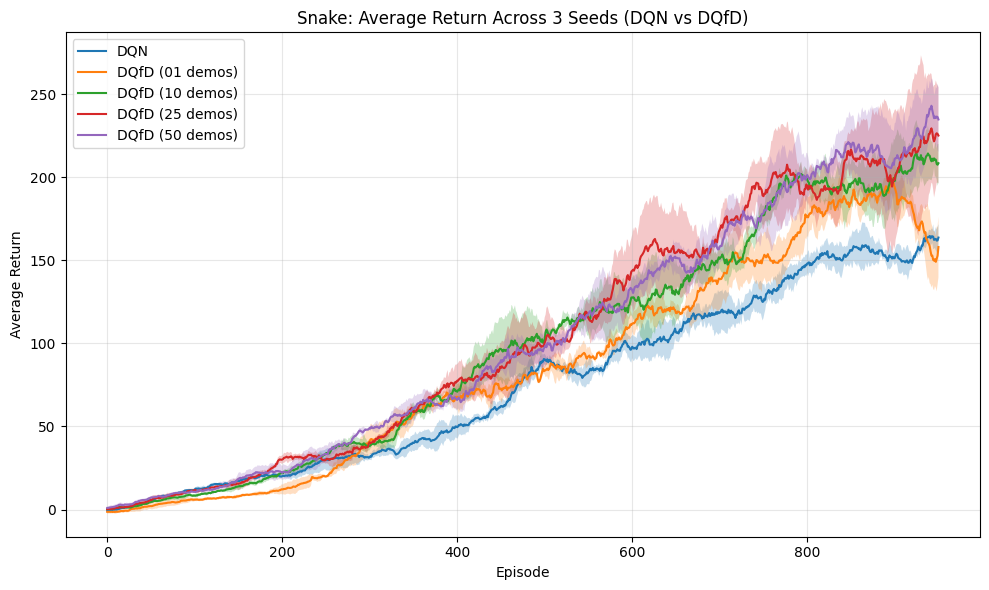

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


def load_rewards_from_results_folder(folder_path):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.

    Returns:
        rewards_per_seed: list of lists
            One reward curve per seed.
    """
    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    if "runs" not in results:
        raise KeyError(f"'runs' key not found in {results_file}")

    rewards_per_seed = []
    for run in results["runs"]:
        if "episode_rewards" in run:
            rewards_per_seed.append(run["episode_rewards"])
        else:
            raise KeyError(f"'episode_rewards' missing in one run from {results_file}")

    return rewards_per_seed


def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)
    if window <= 1:
        return x
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_compare_smoothed_rewards(
    train_rewards_list,
    labels=None,
    window=100,
    xlabel="Episode",
    ylabel="Average Return",
    title="Snake: DQN vs DQfD",
):
    """
    Plot comparison of multiple reward curves (mean ± std across seeds).

    Args:
        train_rewards_list : list[list[list[float]]]
            Outer list over methods.
            Each element is a list over seeds,
            where each seed is a reward sequence.

        labels : list[str] or None
            Labels for each curve.

        window : int
            Moving-average smoothing window.
    """
    if labels is None:
        labels = [f"Method {i+1}" for i in range(len(train_rewards_list))]

    if len(labels) != len(train_rewards_list):
        raise ValueError("labels must match number of methods")

    def compute_stats(train_rewards):
        smoothed = [moving_average(r, window) for r in train_rewards]
        min_len = min(len(r) for r in smoothed)
        smoothed = np.array([r[:min_len] for r in smoothed], dtype=np.float32)

        avg = np.mean(smoothed, axis=0)
        std = np.std(smoothed, axis=0)
        return avg, std

    stats = [compute_stats(tr) for tr in train_rewards_list]

    min_len = min(len(avg) for avg, _ in stats)
    x = np.arange(min_len)

    plt.figure(figsize=(10, 6))

    for (avg, std), label in zip(stats, labels):
        avg = avg[:min_len]
        std = std[:min_len]

        plt.plot(x, avg, label=label)
        plt.fill_between(x, avg - std, avg + std, alpha=0.25)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Set your 5 Snake experiment folders here
# ---------------------------------------------------------
experiment_folders = [
    "dqn_snake_3seeds",
    "dqfd_snake_01_3seeds",
    "dqfd_snake_10_3seeds",
    "dqfd_snake_25_3seeds",
    "dqfd_snake_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load reward curves from all folders
all_rewards = [load_rewards_from_results_folder(folder) for folder in experiment_folders]

# Plot
plot_compare_smoothed_rewards(
    train_rewards_list=all_rewards,
    labels=labels,
    window=50,
    xlabel="Episode",
    ylabel="Average Return",
    title="Snake: Average Return Across 3 Seeds (DQN vs DQfD)",
)

In the AVG Return vs Episode plot for Snake, we can clearly observe a learning behavior across all models. However, it is evident that DQfD, in all of its variants, outperforms DQN alone.

Another interesting finding is that, before episode 300, the 01 Demo DQfD model was the worst-performing model, likely due to overfitting to that single experience, particularly if it was a low-quality demonstration. However, later on, we observe that it surpasses DQN, suggesting that even a poor demonstration can be beneficial in the long run, likely due to the structural advantages introduced by the DQfD framework.

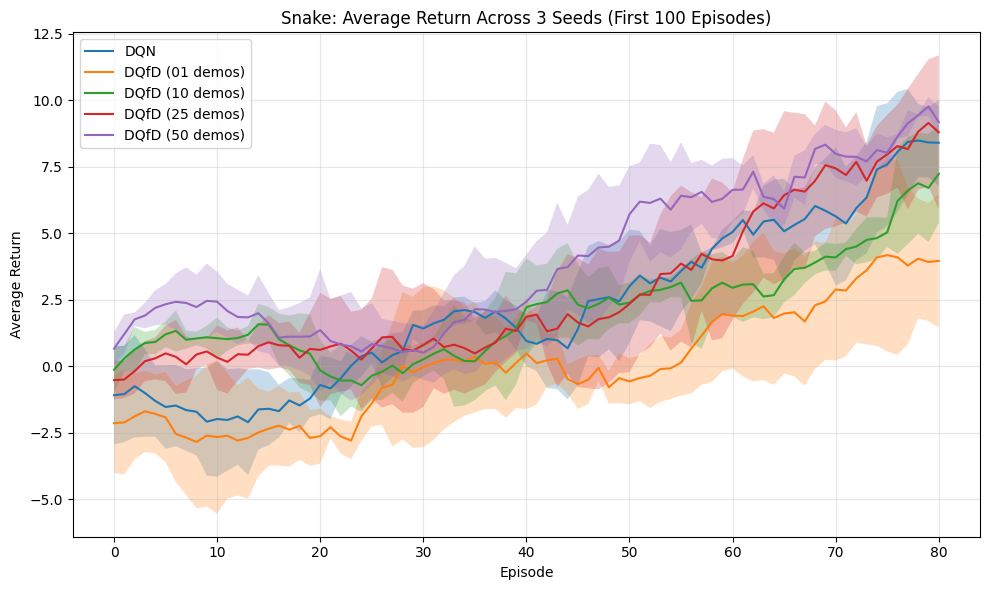

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


MAX_EPISODES = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """

    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    if "runs" not in results:
        raise KeyError(f"'runs' key not found in {results_file}")

    rewards_per_seed = []

    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[:max_episodes]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)

    if window <= 1:
        return x

    if len(x) < window:
        return x

    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_compare_smoothed_rewards(
    train_rewards_list,
    labels=None,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="Snake: DQN vs DQfD",
):

    if labels is None:
        labels = [f"Method {i+1}" for i in range(len(train_rewards_list))]

    if len(labels) != len(train_rewards_list):
        raise ValueError("labels must match number of methods")

    def compute_stats(train_rewards):

        smoothed = [moving_average(r, window) for r in train_rewards]

        min_len = min(len(r) for r in smoothed)
        smoothed = np.array([r[:min_len] for r in smoothed], dtype=np.float32)

        avg = np.mean(smoothed, axis=0)
        std = np.std(smoothed, axis=0)

        return avg, std

    stats = [compute_stats(tr) for tr in train_rewards_list]

    min_len = min(len(avg) for avg, _ in stats)
    x = np.arange(min_len)

    plt.figure(figsize=(10, 6))

    for (avg, std), label in zip(stats, labels):

        avg = avg[:min_len]
        std = std[:min_len]

        plt.plot(x, avg, label=label)
        plt.fill_between(x, avg - std, avg + std, alpha=0.25)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Snake experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_snake_3seeds",
    "dqfd_snake_01_3seeds",
    "dqfd_snake_10_3seeds",
    "dqfd_snake_25_3seeds",
    "dqfd_snake_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]


# Load only first 100 episodes
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=MAX_EPISODES)
    for folder in experiment_folders
]


plot_compare_smoothed_rewards(
    train_rewards_list=all_rewards,
    labels=labels,
    window=20,
    xlabel="Episode",
    ylabel="Average Return",
    title="Snake: Average Return Across 3 Seeds (First 100 Episodes)",
)

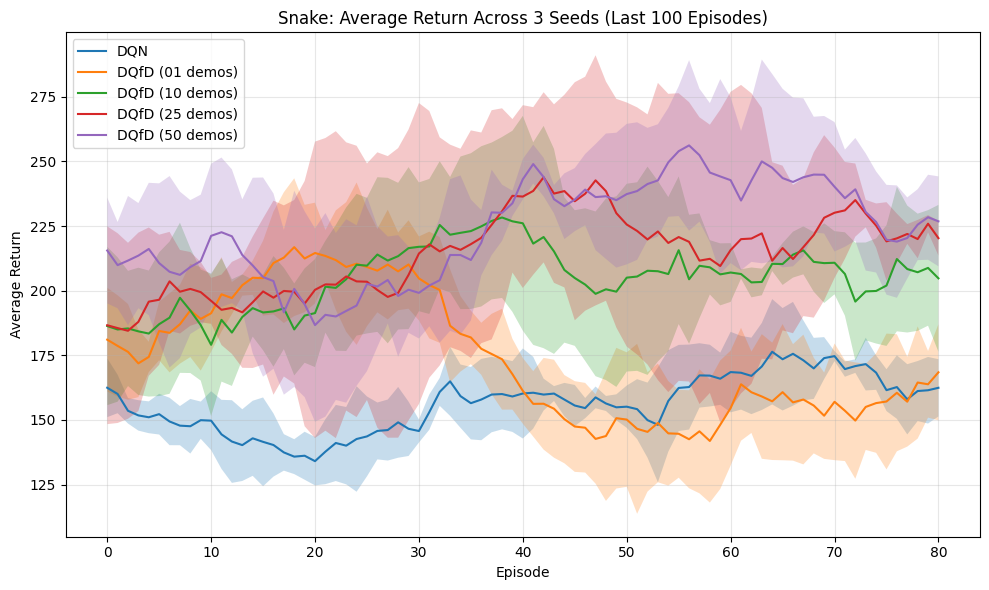

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


MAX_EPISODES = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """

    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    if "runs" not in results:
        raise KeyError(f"'runs' key not found in {results_file}")

    rewards_per_seed = []

    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[-max_episodes:]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)

    if window <= 1:
        return x

    if len(x) < window:
        return x

    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_compare_smoothed_rewards(
    train_rewards_list,
    labels=None,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="Snake: DQN vs DQfD",
):

    if labels is None:
        labels = [f"Method {i+1}" for i in range(len(train_rewards_list))]

    if len(labels) != len(train_rewards_list):
        raise ValueError("labels must match number of methods")

    def compute_stats(train_rewards):

        smoothed = [moving_average(r, window) for r in train_rewards]

        min_len = min(len(r) for r in smoothed)
        smoothed = np.array([r[:min_len] for r in smoothed], dtype=np.float32)

        avg = np.mean(smoothed, axis=0)
        std = np.std(smoothed, axis=0)

        return avg, std

    stats = [compute_stats(tr) for tr in train_rewards_list]

    min_len = min(len(avg) for avg, _ in stats)
    x = np.arange(min_len)

    plt.figure(figsize=(10, 6))

    for (avg, std), label in zip(stats, labels):

        avg = avg[:min_len]
        std = std[:min_len]

        plt.plot(x, avg, label=label)
        plt.fill_between(x, avg - std, avg + std, alpha=0.25)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Snake experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_snake_3seeds",
    "dqfd_snake_01_3seeds",
    "dqfd_snake_10_3seeds",
    "dqfd_snake_25_3seeds",
    "dqfd_snake_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]


# Load only first 100 episodes
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=MAX_EPISODES)
    for folder in experiment_folders
]


plot_compare_smoothed_rewards(
    train_rewards_list=all_rewards,
    labels=labels,
    window=20,
    xlabel="Episode",
    ylabel="Average Return",
    title="Snake: Average Return Across 3 Seeds (Last 100 Episodes)",
)

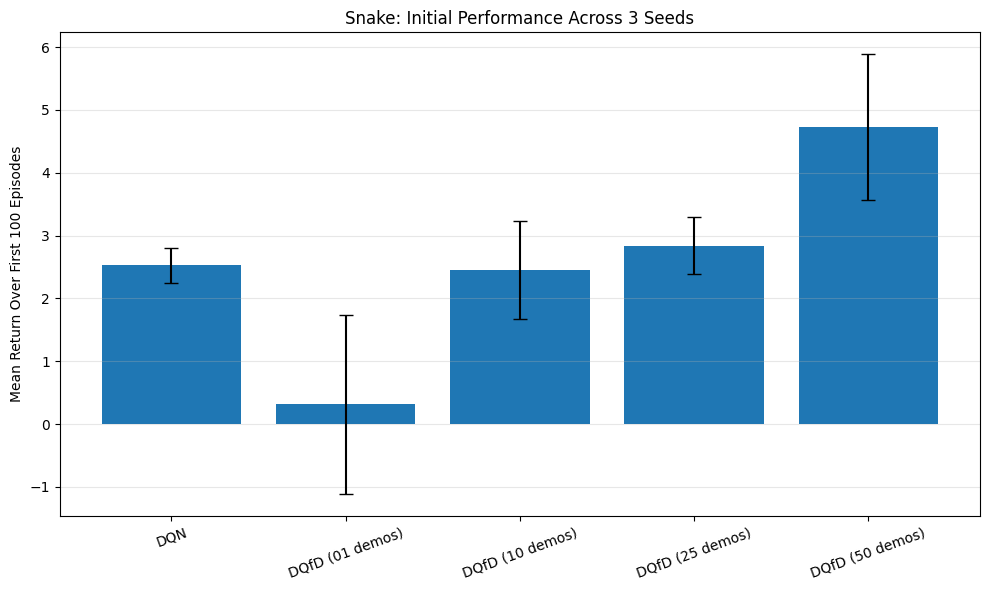

Initial performance = mean reward over first 100 episodes

DQN                | mean = 2.524 | std = 0.271 | per-seed = [2.5069823 2.864768  2.2014713]
DQfD (01 demos)    | mean = 0.318 | std = 1.426 | per-seed = [-1.6987153  1.3022822  1.3497901]
DQfD (10 demos)    | mean = 2.458 | std = 0.782 | per-seed = [3.3165882 2.63253   1.4253725]
DQfD (25 demos)    | mean = 2.841 | std = 0.450 | per-seed = [2.5824292 3.4735675 2.4679358]
DQfD (50 demos)    | mean = 4.722 | std = 1.163 | per-seed = [3.8899314 3.909743  6.367569 ]


In [57]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


INITIAL_WINDOW = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """
    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    rewards_per_seed = []
    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[:max_episodes]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def compute_initial_performance_stats(rewards_per_seed, initial_window=100):
    """
    For each seed, compute the mean reward over the last `initial_window` episodes.
    Then compute mean and std across seeds.
    """
    per_seed_final_means = []

    for rewards in rewards_per_seed:
        rewards = np.asarray(rewards, dtype=np.float32)

        if len(rewards) < initial_window:
            seed_mean = np.mean(rewards)
        else:
            seed_mean = np.mean(rewards[:initial_window])

        per_seed_final_means.append(seed_mean)

    per_seed_final_means = np.asarray(per_seed_final_means, dtype=np.float32)

    return {
        "per_seed_final_means": per_seed_final_means,
        "mean": float(np.mean(per_seed_final_means)),
        "std": float(np.std(per_seed_final_means)),
    }


def plot_initial_performance_bar(
    all_rewards,
    labels,
    initial_window=100,
    ylabel="Final Average Return",
    title="Final Performance Comparison",
):
    stats = [compute_initial_performance_stats(r, initial_window=initial_window) for r in all_rewards]

    means = [s["mean"] for s in stats]
    stds = [s["std"] for s in stats]

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 6))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels, rotation=20)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Initial performance = mean reward over first {initial_window} episodes\n")
    for label, s in zip(labels, stats):
        print(f"{label:18s} | mean = {s['mean']:.3f} | std = {s['std']:.3f} | per-seed = {s['per_seed_final_means']}")


# ---------------------------------------------------------
# Snake experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_snake_3seeds",
    "dqfd_snake_01_3seeds",
    "dqfd_snake_10_3seeds",
    "dqfd_snake_25_3seeds",
    "dqfd_snake_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load full reward curves
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=None)
    for folder in experiment_folders
]

# Plot final performance bar chart
plot_initial_performance_bar(
    all_rewards=all_rewards,
    labels=labels,
    initial_window=INITIAL_WINDOW,
    ylabel="Mean Return Over First 100 Episodes",
    title="Snake: Initial Performance Across 3 Seeds",
)

In the Initial Performance plot for Snake, we can observe that during the first 100 episodes, the best results are achieved by DQfD with 50 demonstration episodes, which corresponds to the model with the largest amount of prior experience.

Then, performance generally decreases as the number of demonstrations decreases. However, there is one exception: DQfD with 1 demonstration performs worse than DQN and exhibits very high variance, in fact the highest among all models. This likely reflects instability caused by relying on a single, potentially low-quality demonstration.

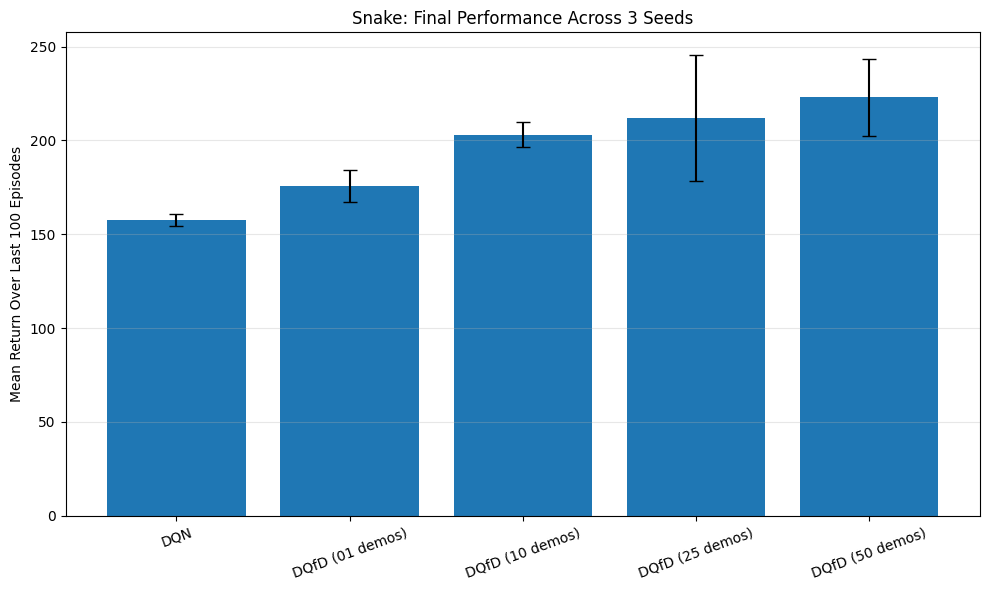

Final performance = mean reward over last 100 episodes

DQN                | mean = 157.525 | std = 3.333 | per-seed = [159.85632 152.8113  159.90709]
DQfD (01 demos)    | mean = 175.965 | std = 8.554 | per-seed = [187.44327 173.5344  166.9175 ]
DQfD (10 demos)    | mean = 203.099 | std = 6.557 | per-seed = [194.55652 204.24771 210.49384]
DQfD (25 demos)    | mean = 211.873 | std = 33.488 | per-seed = [171.7055  253.68385 210.2302 ]
DQfD (50 demos)    | mean = 222.976 | std = 20.397 | per-seed = [195.967   227.71019 245.25133]


In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


FINAL_WINDOW = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """
    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    rewards_per_seed = []
    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[:max_episodes]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def compute_final_performance_stats(rewards_per_seed, final_window=100):
    """
    For each seed, compute the mean reward over the last `final_window` episodes.
    Then compute mean and std across seeds.
    """
    per_seed_final_means = []

    for rewards in rewards_per_seed:
        rewards = np.asarray(rewards, dtype=np.float32)

        if len(rewards) < final_window:
            seed_mean = np.mean(rewards)
        else:
            seed_mean = np.mean(rewards[-final_window:])

        per_seed_final_means.append(seed_mean)

    per_seed_final_means = np.asarray(per_seed_final_means, dtype=np.float32)

    return {
        "per_seed_final_means": per_seed_final_means,
        "mean": float(np.mean(per_seed_final_means)),
        "std": float(np.std(per_seed_final_means)),
    }


def plot_final_performance_bar(
    all_rewards,
    labels,
    final_window=100,
    ylabel="Final Average Return",
    title="Final Performance Comparison",
):
    stats = [compute_final_performance_stats(r, final_window=final_window) for r in all_rewards]

    means = [s["mean"] for s in stats]
    stds = [s["std"] for s in stats]

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 6))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels, rotation=20)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Final performance = mean reward over last {final_window} episodes\n")
    for label, s in zip(labels, stats):
        print(f"{label:18s} | mean = {s['mean']:.3f} | std = {s['std']:.3f} | per-seed = {s['per_seed_final_means']}")


# ---------------------------------------------------------
# Snake experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_snake_3seeds",
    "dqfd_snake_01_3seeds",
    "dqfd_snake_10_3seeds",
    "dqfd_snake_25_3seeds",
    "dqfd_snake_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load full reward curves
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=None)
    for folder in experiment_folders
]

# Plot final performance bar chart
plot_final_performance_bar(
    all_rewards=all_rewards,
    labels=labels,
    final_window=FINAL_WINDOW,
    ylabel="Mean Return Over Last 100 Episodes",
    title="Snake: Final Performance Across 3 Seeds",
)

For the Final Performance plot of Snake, we can observe that the worst mean return is obtained by DQN. Additionally, in this plot it is evident that the number of demonstrations used as prior experience is directly correlated with the mean return reward, with DQfD using 50 demonstrations achieving the highest performance.